###   by Amjad Al-thobaiti

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import kagglehub
from PIL import UnidentifiedImageError
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

In [2]:
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
data_dir = os.path.join(path, "PetImages")

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.


In [3]:
def safe_image_generator(generator):

    while True:
        try:
            x, y = next(generator)
            yield x, y
        except (UnidentifiedImageError, OSError, Exception):
            continue

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

raw_train_ds = datagen.flow_from_directory(
    data_dir, target_size=(150, 150), batch_size=32, class_mode='binary', subset='training'
)

raw_val_ds = datagen.flow_from_directory(
    data_dir, target_size=(150, 150), batch_size=32, class_mode='binary', subset='validation'
)

train_ds = safe_image_generator(raw_train_ds)
val_ds = safe_image_generator(raw_val_ds)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

train_steps = raw_train_ds.samples // 32
val_steps = raw_val_ds.samples // 32

history = model.fit(
    train_ds,
    steps_per_epoch=train_steps,
    epochs=10,
    validation_data=val_ds,
    validation_steps=val_steps,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
383/625 ━━━━━━━━━━━━━━━━━━━━ 51s 211ms/step - accuracy: 0.5663 - loss: 0.6885

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.5956 - loss: 0.6637

625/625 ━━━━━━━━━━━━━━━━━━━━ 171s 264ms/step - accuracy: 0.5957 - loss: 0.6636 - val_accuracy: 0.7605 - val_loss: 0.4969
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7511 - loss: 0.5096

625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.7512 - loss: 0.5096 - val_accuracy: 0.7983 - val_loss: 0.4323
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8107 - loss: 0.4266

625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.8107 - loss: 0.4266 - val_accuracy: 0.8190 - val_loss: 0.3987
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8355 - loss: 0.3642

625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.8355 - loss: 0.3642 - val_accuracy: 0.8263 - val_loss: 0.3840
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8698 - loss: 0.3019

625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.8698 - loss: 0.3019 - val_accuracy: 0.8426 - val_loss: 0.3704
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.9018 - loss: 0.2371 - val_accuracy: 0.8402 - val_loss: 0.4001
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.9265 - loss: 0.1800 - val_accuracy: 0.8434 - val_loss: 0.4359
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.9443 - loss: 0.1400 - val_accuracy: 0.8478 - val_loss: 0.4710


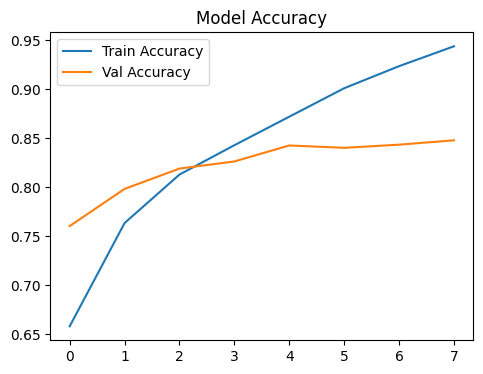

In [6]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

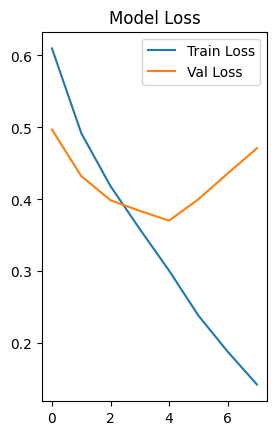

In [7]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [8]:
results = model.evaluate(val_ds, steps=val_steps)
print(f"Loss: {results[0]:.4f}")
print(f"Accuracy: {results[1]*100:.2f}%")

156/156 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8506 - loss: 0.3571
Loss: 0.3715
Accuracy: 84.26%


Saving dog.jpg to dog (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step


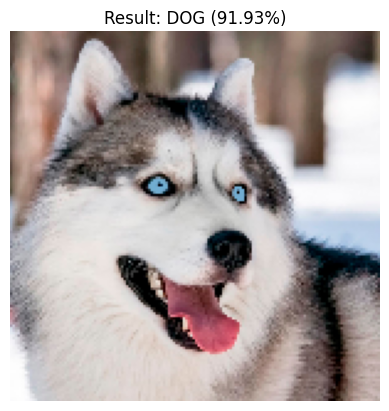

In [12]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    img = load_img(path, target_size=(150, 150))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x /= 255.0

    classes = model.predict(x)

    plt.imshow(img)
    plt.axis('off')
    if classes[0] > 0.5:
        plt.title(f"Result: DOG ({classes[0][0]*100:.2f}%)")
    else:
        plt.title(f"Result: CAT ({(1-classes[0][0])*100:.2f}%)")
    plt.show()

Saving cat.png to cat (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


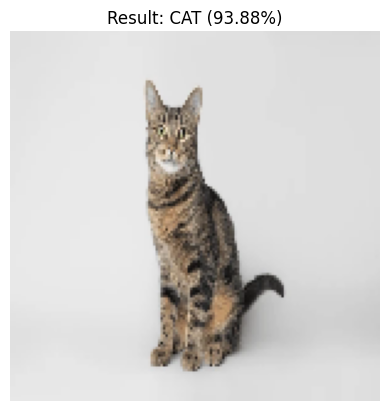

In [13]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    img = load_img(path, target_size=(150, 150))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x /= 255.0

    classes = model.predict(x)

    plt.imshow(img)
    plt.axis('off')
    if classes[0] > 0.5:
        plt.title(f"Result: DOG ({classes[0][0]*100:.2f}%)")
    else:
        plt.title(f"Result: CAT ({(1-classes[0][0])*100:.2f}%)")
    plt.show()